# Using DBSOD to estimate outlierness of new data

We will use the same dataset as in `01. Real Data.ipynb` and will estimate outlierness scores for the new data points, effectively creating an outlierness heatmap. 

---
Import `scikit-learn` estimators, plotting utils and `DBSOD`

In [1]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from dbsod import DBSOD

Load data and fit `DBSOD`

In [2]:
X = load_wine()["data"][:, [1, 2]]  # two clusters
min_max_scaler = MinMaxScaler()

model = DBSOD(
    eps_space=np.linspace(0., 0.1, 100),
    min_pts=3,
)
model.fit(X=min_max_scaler.fit_transform(X))  # normalize data before fitting DBSOD
None

Building neighborhood graph:                        [====================] 100% (0 it/s)           
Identifying outliers for each value in `eps_space`: [====================] 100% (0 it/s)           


Estimate outlierness for a grid of data points to plot as a heatmap.

In [3]:
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
resolution = 1000

# prepare a grid of points
x, y = np.meshgrid(
    np.linspace(x_min, x_max, resolution),
    np.linspace(y_min, y_max, resolution)
)
points = np.column_stack([x.ravel(), y.ravel()])

# estimate outlierness score for each new point
predictions = model.predict(min_max_scaler.transform(points))

Estimating outlierness score for each point:        [====================] 100% (4.6132e+06 it/s)           


Visualize result

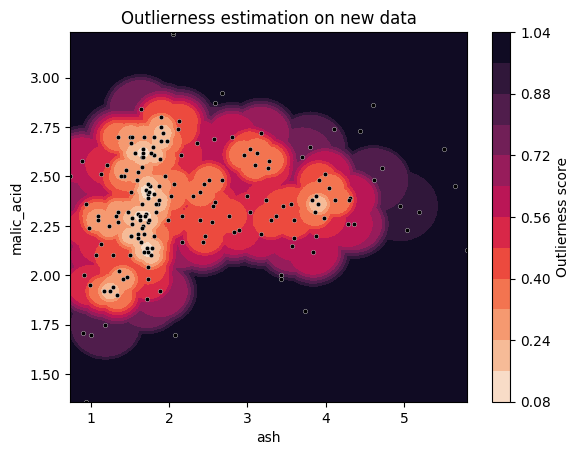

In [4]:
%matplotlib inline

# plot outlierness heatmap and original data points
fig, ax = plt.subplots()
contour = plt.contourf(
    x, y,
    predictions.reshape(resolution, resolution),
    cmap=sns.color_palette("rocket_r", as_cmap=True),
    levels=10,
)
scatter = sns.scatterplot(x=X[:, 0], y=X[:, 1], color="k", s=10)

ax.set(
    xlabel="ash",
    ylabel="malic_acid",
    title="Outlierness estimation on new data",
)
fig.colorbar(contour, ax=ax).set_label("Outlierness score")

plt.savefig('figures/02-predicting-on-new-data.png')
plt.show()

_Note: This example is an adapted version of a [scikit-learn real world outlier detection example](https://scikit-learn.org/stable/auto_examples/applications/plot_outlier_detection_wine.html) with applied `DBSOD` to the data points (visualized outlierness score)._